# Exploratory clustering

In this notebook, we explore different clustering models. Ultimately, we refine and settle on two different models - one with K=2 and the other with K=4.

### Setup

In [1]:
# ------------------------------
# 0. Setup
# ------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from tqdm import tqdm
import random
from scipy.optimize import linear_sum_assignment
from collections import defaultdict
import joblib
from sklearn.manifold import TSNE
import umap

# Load processed ERA5 data
file_path = "../processed/era5_features.csv"
df = pd.read_csv(file_path)

/Users/dannes/etc-cyclones/etc-impacts-great-lakes/env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Feature Selection

In [2]:
# ------------------------------
# 1. Feature Selection
# ------------------------------
features_to_cluster = [
    'min_p_cent', 
    'max_p_grad', 
    'max_radius', 
    'max_uv',
    'fraction_of_time_in_GLR', 
    'maturity_glr0_minus_genesis_ratio'
]

X_scaled = df[features_to_cluster].dropna().copy()

In [3]:
# ------------------------------
# 2. Subsampling & GMM Clustering
# ------------------------------
n_subsamples = 30
sample_frac = 0.8
k_range = range(2, 7)

results = []

for k in k_range:
    for _ in tqdm(range(n_subsamples), desc=f"K={k}"):
        sample_idx = random.sample(range(len(X_scaled)), int(sample_frac * len(X_scaled)))
        X_sample = X_scaled.iloc[sample_idx]

        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=5)
        labels = gmm.fit_predict(X_sample)

        sil = silhouette_score(X_sample, labels)
        log_likelihood = gmm.score(X_sample) * len(X_sample)
        bic = gmm.bic(X_sample)
        aic = gmm.aic(X_sample)

        results.append({
            "K": k,
            "silhouette": sil,
            "log_likelihood": log_likelihood,
            "bic": bic,
            "aic": aic
        })

K=6: 100%|██████████| 30/30 [00:13<00:00,  2.17it/s]


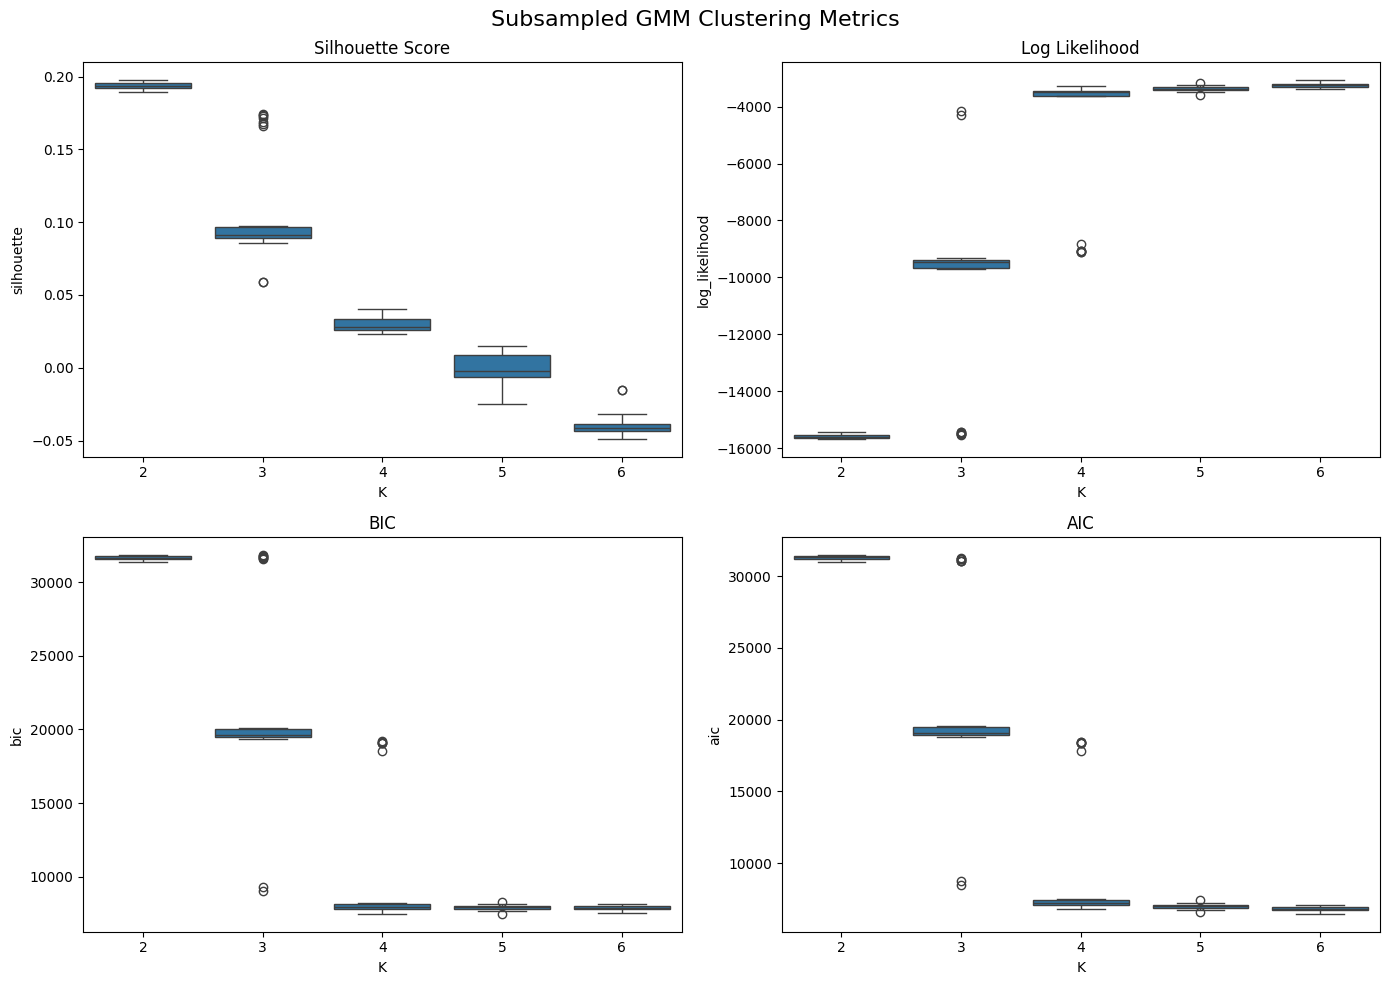

In [4]:
# ------------------------------
# 3. Visualize Metrics
# ------------------------------
metrics_df = pd.DataFrame(results)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=metrics_df, x="K", y="silhouette", ax=axs[0, 0])
axs[0, 0].set_title("Silhouette Score")
sns.boxplot(data=metrics_df, x="K", y="log_likelihood", ax=axs[0, 1])
axs[0, 1].set_title("Log Likelihood")
sns.boxplot(data=metrics_df, x="K", y="bic", ax=axs[1, 0])
axs[1, 0].set_title("BIC")
sns.boxplot(data=metrics_df, x="K", y="aic", ax=axs[1, 1])
axs[1, 1].set_title("AIC")

plt.suptitle("Subsampled GMM Clustering Metrics", fontsize=16)
plt.tight_layout()
plt.show()

# Developing the K=2 Model

Stability K=2: 100%|██████████| 30/30 [00:03<00:00,  8.82it/s]


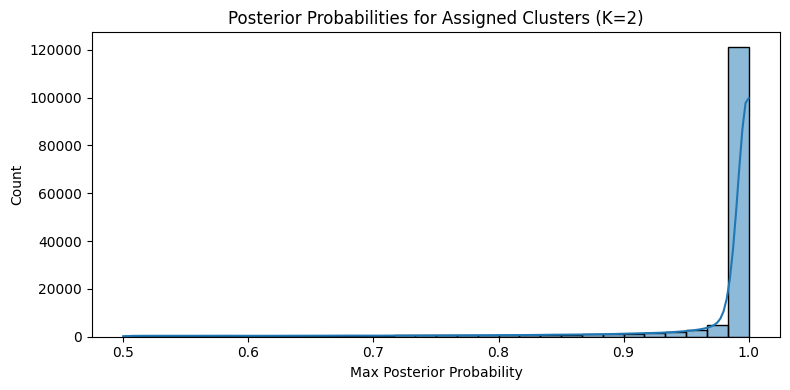

In [ ]:
# ------------------------------
# 4. Cluster Stability at K=2
# ------------------------------
k_best = 2
label_matrix_k2 = []
posterior_probs_k2 = []
subsample_indices_k2 = []

for _ in tqdm(range(n_subsamples), desc=f"Stability K={k_best}"):
    sample_idx = random.sample(range(len(X_scaled)), int(sample_frac * len(X_scaled)))
    X_sample = X_scaled.iloc[sample_idx]

    gmm_k4 = GaussianMixture(n_components=k_best, covariance_type='full', random_state=42, n_init=5)
    gmm_k4.fit(X_sample)
    probs_k2 = gmm_k2.predict_proba(X_sample)
    labels_k2 = gmm_k2.predict(X_sample)

    label_matrix_k2.append(labels_k2)
    posterior_probs_k2.append(probs_k2.max(axis=1))
    subsample_indices_k2.append(sample_idx)

# Plot histogram of posterior max probabilities
plt.figure(figsize=(8, 4))
all_probs_k2 = np.concatenate(posterior_probs_k2)
sns.histplot(all_probs_k2, bins=30, kde=True)
plt.title(f"Posterior Probabilities for Assigned Clusters (K={k_best})")
plt.xlabel("Max Posterior Probability")
plt.tight_layout()
plt.show()

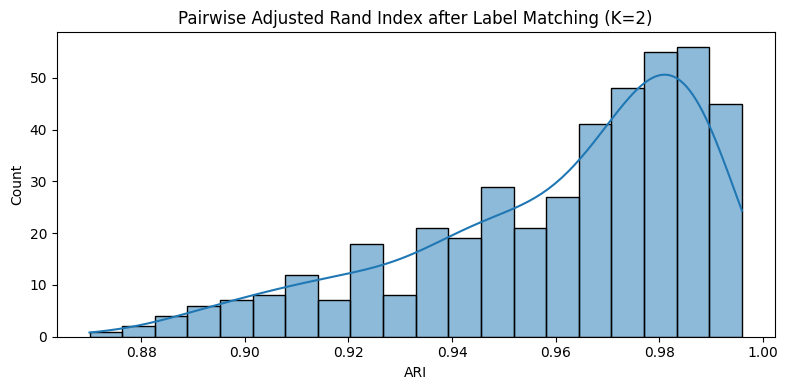

In [6]:
# ------------------------------
# 5. Cluster Label Agreement (Hungarian-matched ARI, K=2)
# ------------------------------
def match_labels(labels1, labels2, n_clusters):
    cost_matrix = np.zeros((n_clusters, n_clusters))
    for i in range(n_clusters):
        for j in range(n_clusters):
            cost_matrix[i, j] = -np.sum((labels1 == i) & (labels2 == j))
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    label_map = {j: i for i, j in zip(row_ind, col_ind)}
    matched = np.array([label_map[label] for label in labels2])
    return matched

n_runs = len(label_matrix_k2)
mapped_ari_scores_k2 = []

for i in range(n_runs):
    for j in range(i + 1, n_runs):
        idx_i = subsample_indices_k2[i]
        idx_j = subsample_indices_k2[j]
        shared_idx = list(set(idx_i) & set(idx_j))
        if not shared_idx:
            continue
        idx_i_map = [idx_i.index(x) for x in shared_idx]
        idx_j_map = [idx_j.index(x) for x in shared_idx]
        labels_i = label_matrix_k2[i][idx_i_map]
        labels_j = label_matrix_k2[j][idx_j_map]
        labels_j_matched = match_labels(labels_i, labels_j, k_best)
        ari = adjusted_rand_score(labels_i, labels_j_matched)
        mapped_ari_scores_k2.append(ari)

plt.figure(figsize=(8, 4))
sns.histplot(mapped_ari_scores_k2, bins=20, kde=True)
plt.title(f"Pairwise Adjusted Rand Index after Label Matching (K={k_best})")
plt.xlabel("ARI")
plt.tight_layout()
plt.show()

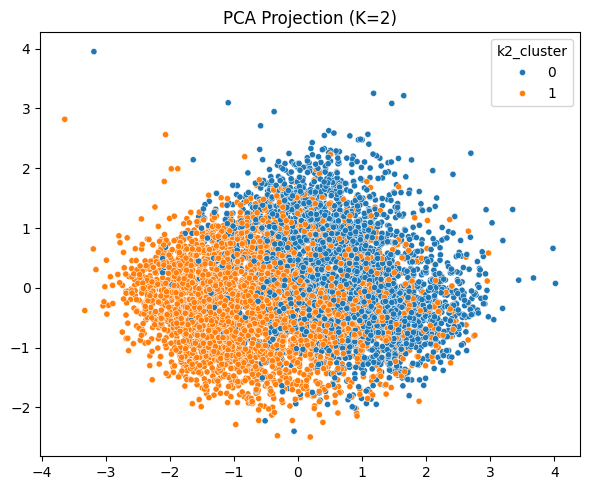

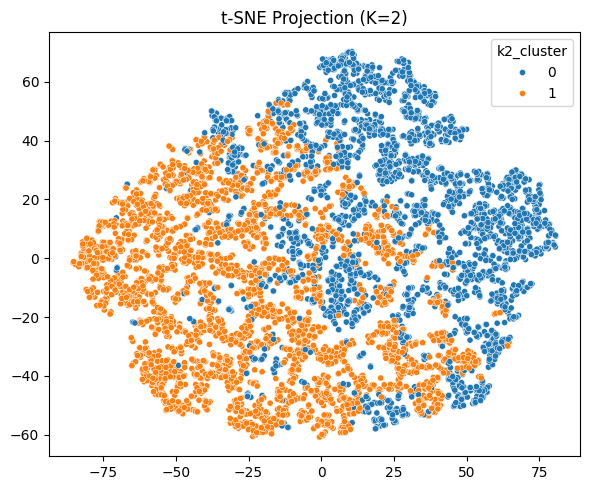

/Users/dannes/etc-cyclones/etc-impacts-great-lakes/env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/dannes/etc-cyclones/etc-impacts-great-lakes/env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


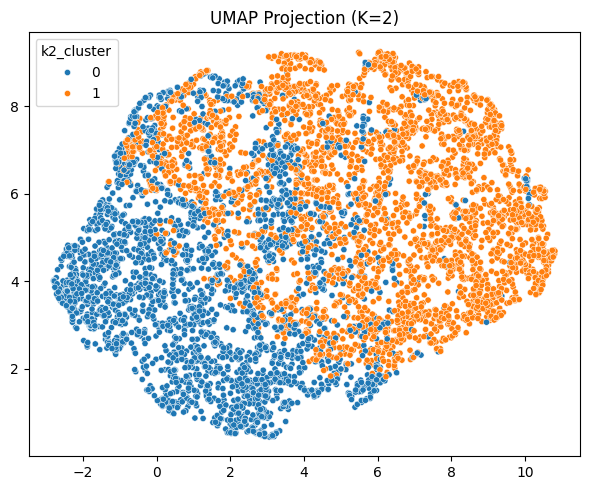

In [7]:
# ------------------------------
# 6. PCA, t-SNE, and UMAP for K=2
# ------------------------------
# Fit on full dataset for K=2
final_gmm_k2 = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=5)
final_gmm_k2.fit(X_scaled)
df['k2_cluster'] = final_gmm_k2.predict(X_scaled)
df['k2_posterior'] = final_gmm_k2.predict_proba(X_scaled).max(axis=1)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['k2_cluster'], palette='tab10', s=20)
plt.title("PCA Projection (K=2)")
plt.tight_layout()
plt.show()

# t-SNE
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['k2_cluster'], palette='tab10', s=20)
plt.title("t-SNE Projection (K=2)")
plt.tight_layout()
plt.show()

# UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=df['k2_cluster'], palette='tab10', s=20)
plt.title("UMAP Projection (K=2)")
plt.tight_layout()
plt.show()

Using 5369 high-confidence points out of 6136 total.


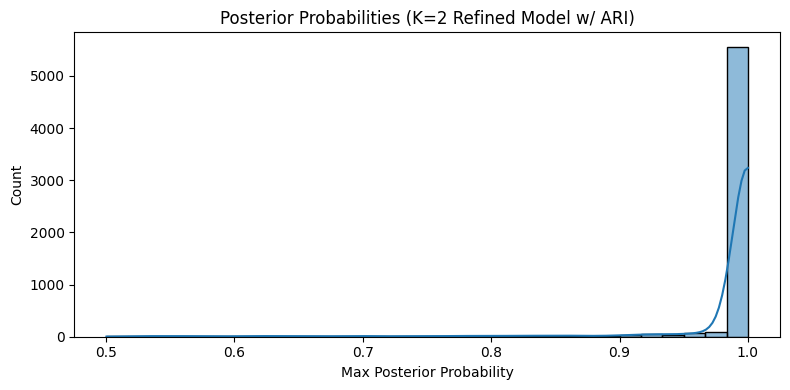

In [8]:
# ------------------------------
# 7. Retrain K=2 on High-Confidence Points
# ------------------------------
confidence_thresh_k2 = 0.95
ari_thresh_k2 = 0.85

# Build ARI mask from earlier analysis
ari_mask_k2 = np.zeros(len(X_scaled), dtype=bool)
for idx_set, probs in zip(subsample_indices_k2, posterior_probs_k2):
    for i, idx in enumerate(idx_set):
        if probs[i] >= confidence_thresh_k2:
            ari_mask_k2[idx] = True

# Combine posterior and ARI masks
confident_mask_k2 = (df['k2_posterior'] >= confidence_thresh_k2) & ari_mask_k2

print(f"Using {confident_mask_k2.sum()} high-confidence points out of {len(df)} total.")

# Fit new GMM on confident data only
X_conf_k2 = X_scaled[confident_mask_k2]
gmm_k2_refined = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=5)
gmm_k2_refined.fit(X_conf_k2)

# Predict labels and posteriors for all data
df['k2_refined_cluster'] = gmm_k2_refined.predict(X_scaled)
df['k2_refined_posterior'] = gmm_k2_refined.predict_proba(X_scaled).max(axis=1)

# Plot refined posteriors
plt.figure(figsize=(8, 4))
sns.histplot(df['k2_refined_posterior'], bins=30, kde=True)
plt.title("Posterior Probabilities (K=2 Refined Model w/ ARI)")
plt.xlabel("Max Posterior Probability")
plt.tight_layout()
plt.show()


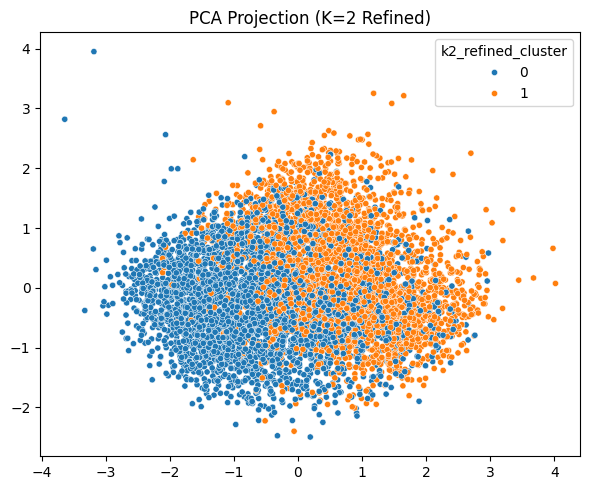

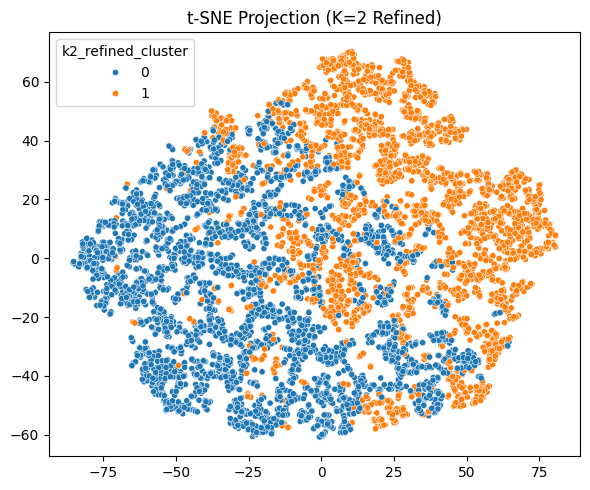

/Users/dannes/etc-cyclones/etc-impacts-great-lakes/env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


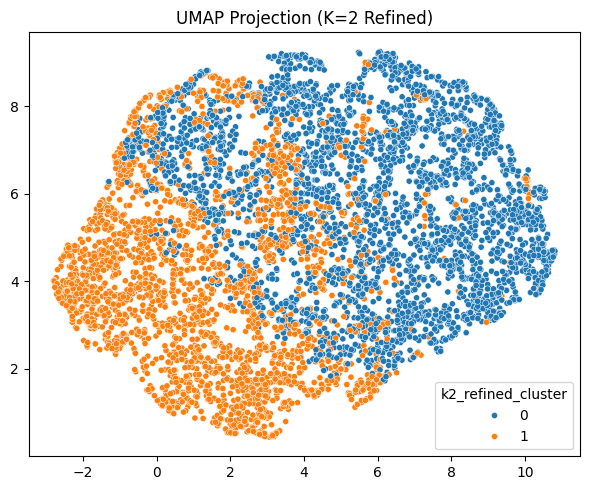

In [9]:
# ------------------------------
# 8. PCA, t-SNE, and UMAP (Refined K=2)
# ------------------------------
# PCA
X_pca_refined = pca.fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca_refined[:, 0], y=X_pca_refined[:, 1], hue=df['k2_refined_cluster'], palette='tab10', s=20)
plt.title("PCA Projection (K=2 Refined)")
plt.tight_layout()
plt.show()

# t-SNE
X_tsne_refined = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_tsne_refined[:, 0], y=X_tsne_refined[:, 1], hue=df['k2_refined_cluster'], palette='tab10', s=20)
plt.title("t-SNE Projection (K=2 Refined)")
plt.tight_layout()
plt.show()

# UMAP
X_umap_refined = umap_model.fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_umap_refined[:, 0], y=X_umap_refined[:, 1], hue=df['k2_refined_cluster'], palette='tab10', s=20)
plt.title("UMAP Projection (K=2 Refined)")
plt.tight_layout()
plt.show()

# Developing the K=4 Model

In [ ]:
# ------------------------------
# 4. Cluster Stability at K=4
# ------------------------------
k_best = 4
label_matrix_k4 = []
posterior_probs_k4 = []
subsample_indices_k4 = []

for _ in tqdm(range(n_subsamples), desc=f"Stability K={k_best}"):
    sample_idx = random.sample(range(len(X_scaled)), int(sample_frac * len(X_scaled)))
    X_sample = X_scaled.iloc[sample_idx]

    gmm_k4 = GaussianMixture(n_components=k_best, covariance_type='full', random_state=42, n_init=5)
    gmm_k4.fit(X_sample)
    probs_k4 = gmm_k4.predict_proba(X_sample)
    labels_k4 = gmm_k4.predict(X_sample)

    label_matrix_k4.append(labels_k4)
    posterior_probs_k4.append(probs_k4.max(axis=1))
    subsample_indices_k4.append(sample_idx)

# Plot histogram of posterior max probabilities
plt.figure(figsize=(8, 4))
all_probs_k4 = np.concatenate(posterior_probs_k4)
sns.histplot(all_probs_k4, bins=30, kde=True)
plt.title(f"Posterior Probabilities for Assigned Clusters (K={k_best})")
plt.xlabel("Max Posterior Probability")
plt.tight_layout()
plt.show()

NameError: name 'tqdm' is not defined

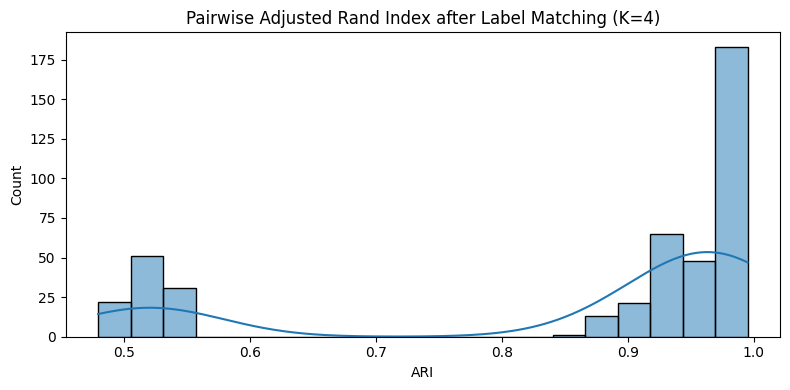

In [ ]:
# ------------------------------
# 5. Cluster Label Agreement (Hungarian-matched ARI)
# ------------------------------
def match_labels(labels1, labels2, n_clusters):
    cost_matrix = np.zeros((n_clusters, n_clusters))
    for i in range(n_clusters):
        for j in range(n_clusters):
            cost_matrix[i, j] = -np.sum((labels1 == i) & (labels2 == j))
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    label_map = {col: row for row, col in zip(row_ind, col_ind)}
    matched = np.array([label_map[label] for label in labels2])
    return matched

n_runs = len(label_matrix_k4)
mapped_ari_scores = []

for i in range(n_runs):
    for j in range(i + 1, n_runs):
        idx_i = subsample_indices# ------------------------------
# 4. Cluster Stability at K=2
# ------------------------------
k_best = 2
label_matrix_k2 = []
posterior_probs_k2 = []
subsample_indices_k2 = []

for _ in tqdm(range(n_subsamples), desc=f"Stability K={k_best}"):
    sample_idx = random.sample(range(len(X_scaled)), int(sample_frac * len(X_scaled)))
    X_sample = X_scaled.iloc[sample_idx]

    gmm_k2 = GaussianMixture(n_components=k_best, covariance_type='full', random_state=42, n_init=5)
    gmm_k2.fit(X_sample)
    probs_k2 = gmm_k2.predict_proba(X_sample)
    labels_k2 = gmm_k2.predict(X_sample)

    label_matrix_k2.append(labels_k2)
    posterior_probs_k2.append(probs_k2.max(axis=1))
    subsample_indices_k2.append(sample_idx)

# Plot histogram of posterior max probabilities
plt.figure(figsize=(8, 4))
all_probs_k2 = np.concatenate(posterior_probs_k2)
sns.histplot(all_probs_k2, bins=30, kde=True)
plt.title(f"Posterior Probabilities for Assigned Clusters (K={k_best})")
plt.xlabel("Max Posterior Probability")
plt.tight_layout()
        idx_j = subsample_indices[j]
        shared_idx = list(set(idx_i) & set(idx_j))
        if not shared_idx:
            continue
        idx_i_map = [idx_i.index(x) for x in shared_idx]
        idx_j_map = [idx_j.index(x) for x in shared_idx]
        labels_i = label_matrix[i][idx_i_map]
        labels_j = label_matrix[j][idx_j_map]
        labels_j_matched = match_labels(labels_i, labels_j, k_best)
        ari = adjusted_rand_score(labels_i, labels_j_matched)
        mapped_ari_scores.append(ari)

plt.figure(figsize=(8, 4))
sns.histplot(mapped_ari_scores, bins=20, kde=True)
plt.title(f"Pairwise Adjusted Rand Index after Label Matching (K={k_best})")
plt.xlabel("ARI")
plt.tight_layout()
plt.show()

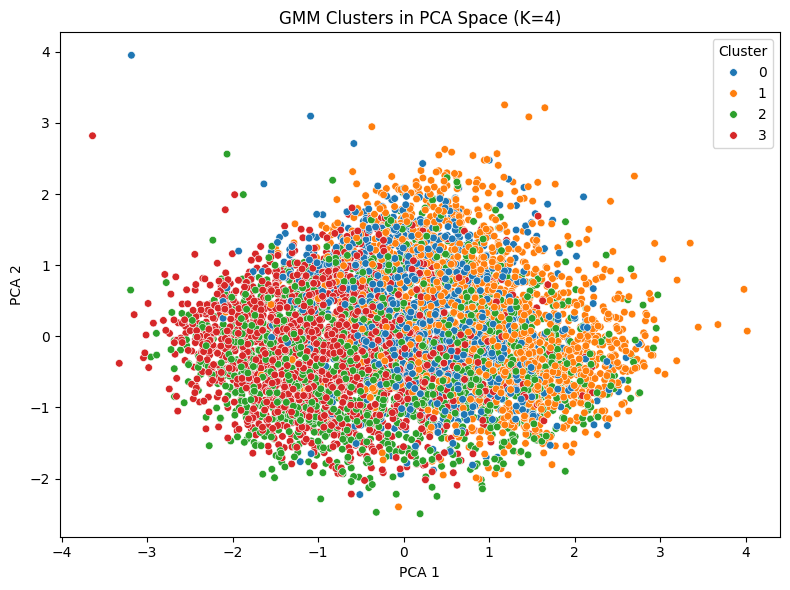

In [12]:
# ------------------------------
# 6. Visualize Cluster Assignments in PCA Space
# ------------------------------
gmm_final = GaussianMixture(n_components=k_best, covariance_type='full', random_state=42, n_init=5)
final_labels = gmm_final.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=final_labels, palette='tab10', s=30)
plt.title(f"GMM Clusters in PCA Space (K={k_best})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


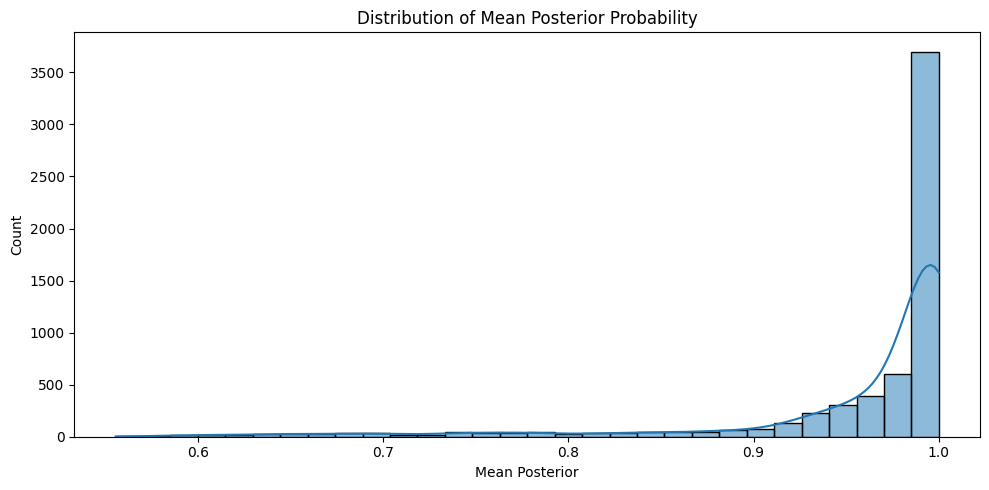

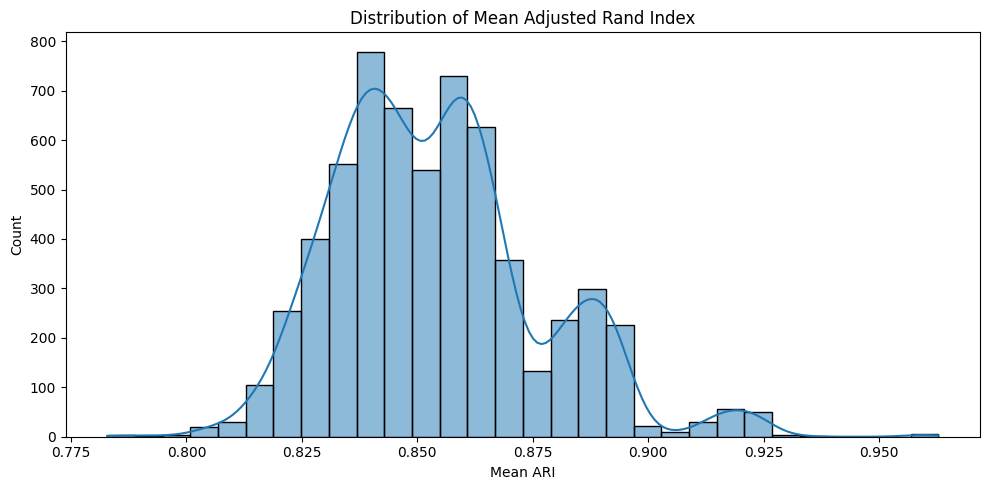

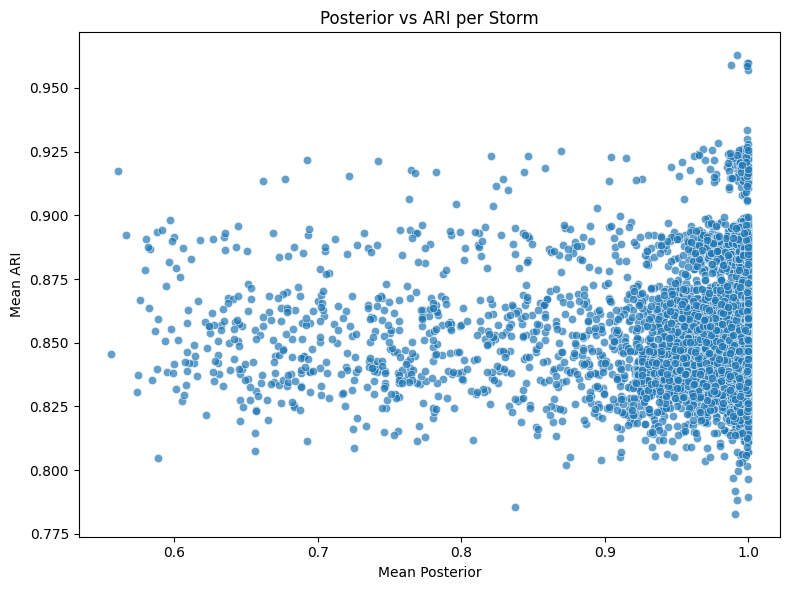

In [13]:
# ------------------------------
# 8. Cluster Label Agreement (Hungarian-matched ARI)
# ------------------------------
def match_labels(labels1, labels2, n_clusters):
    cost_matrix = np.zeros((n_clusters, n_clusters))
    for i in range(n_clusters):
        for j in range(n_clusters):
            cost_matrix[i, j] = -np.sum((labels1 == i) & (labels2 == j))
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    label_map = {col: row for row, col in zip(row_ind, col_ind)}
    matched = np.array([label_map[label] for label in labels2])
    return matched

n_runs = len(label_matrix)
mapped_ari_scores = []
storm_ari_tracker = defaultdict(list)
storm_posterior_tracker = defaultdict(list)

for i in range(n_runs):
    for j in range(i + 1, n_runs):
        idx_i = subsample_indices[i]
        idx_j = subsample_indices[j]
        shared_idx = list(set(idx_i) & set(idx_j))
        if not shared_idx:
            continue
        idx_i_map = [idx_i.index(x) for x in shared_idx]
        idx_j_map = [idx_j.index(x) for x in shared_idx]
        labels_i = label_matrix[i][idx_i_map]
        labels_j = label_matrix[j][idx_j_map]
        labels_j_matched = match_labels(labels_i, labels_j, k_best)
        ari = adjusted_rand_score(labels_i, labels_j_matched)
        mapped_ari_scores.append(ari)
        for s_idx in shared_idx:
            storm_ari_tracker[s_idx].append(ari)

# Aggregate ARI and posterior confidence per storm
for run_idx, sample_idx in enumerate(subsample_indices):
    for i, s_idx in enumerate(sample_idx):
        storm_posterior_tracker[s_idx].append(posterior_probs[run_idx][i])

storm_conf_df = pd.DataFrame({
    'storm_index': list(X_scaled.index),
    'posterior_mean': [np.mean(storm_posterior_tracker.get(i, [np.nan])) for i in X_scaled.index],
    'ari_mean': [np.mean(storm_ari_tracker.get(i, [np.nan])) for i in X_scaled.index],
    'posterior_count': [len(storm_posterior_tracker.get(i, [])) for i in X_scaled.index],
    'ari_count': [len(storm_ari_tracker.get(i, [])) for i in X_scaled.index],
})

# Visualize confidence metrics
plt.figure(figsize=(10, 5))
sns.histplot(storm_conf_df['posterior_mean'], bins=30, kde=True)
plt.title("Distribution of Mean Posterior Probability")
plt.xlabel("Mean Posterior")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(storm_conf_df['ari_mean'], bins=30, kde=True)
plt.title("Distribution of Mean Adjusted Rand Index")
plt.xlabel("Mean ARI")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=storm_conf_df, x='posterior_mean', y='ari_mean', alpha=0.7)
plt.title("Posterior vs ARI per Storm")
plt.xlabel("Mean Posterior")
plt.ylabel("Mean ARI")
plt.tight_layout()
plt.show()

In [14]:
# ------------------------------
# 6.5. Build Confidence Summary for Each Point
# ------------------------------
# Initialize confidence DataFrame
n_points = len(X_scaled)
confidence_data = {
    "avg_post_prob": np.full(n_points, np.nan),
    "avg_ari": np.full(n_points, np.nan),
    "counts": np.zeros(n_points)
}

# Accumulate posteriors and ARI scores for each point
for run_idx, idxs in enumerate(subsample_indices):
    for i, global_idx in enumerate(idxs):
        prob = posterior_probs[run_idx][i]
        confidence_data["counts"][global_idx] += 1
        if np.isnan(confidence_data["avg_post_prob"][global_idx]):
            confidence_data["avg_post_prob"][global_idx] = 0
        confidence_data["avg_post_prob"][global_idx] += prob

# Average posterior
confidence_data["avg_post_prob"] /= np.maximum(confidence_data["counts"], 1)

# Now accumulate ARI per point (simplified: average over all matched pairs it appears in)
point_ari_sums = np.zeros(n_points)
point_ari_counts = np.zeros(n_points)

for i in range(n_runs):
    for j in range(i + 1, n_runs):
        idx_i = subsample_indices[i]
        idx_j = subsample_indices[j]
        shared_idx = list(set(idx_i) & set(idx_j))
        if not shared_idx:
            continue
        idx_i_map = [idx_i.index(x) for x in shared_idx]
        idx_j_map = [idx_j.index(x) for x in shared_idx]
        labels_i = label_matrix[i][idx_i_map]
        labels_j = label_matrix[j][idx_j_map]
        labels_j_matched = match_labels(labels_i, labels_j, k_best)
        ari = adjusted_rand_score(labels_i, labels_j_matched)
        for pt in shared_idx:
            point_ari_sums[pt] += ari
            point_ari_counts[pt] += 1

confidence_data["avg_ari"] = point_ari_sums / np.maximum(point_ari_counts, 1)

# Create final DataFrame
df_confidence = pd.DataFrame(confidence_data)


Using 4816 high-confidence points out of 6136 total.


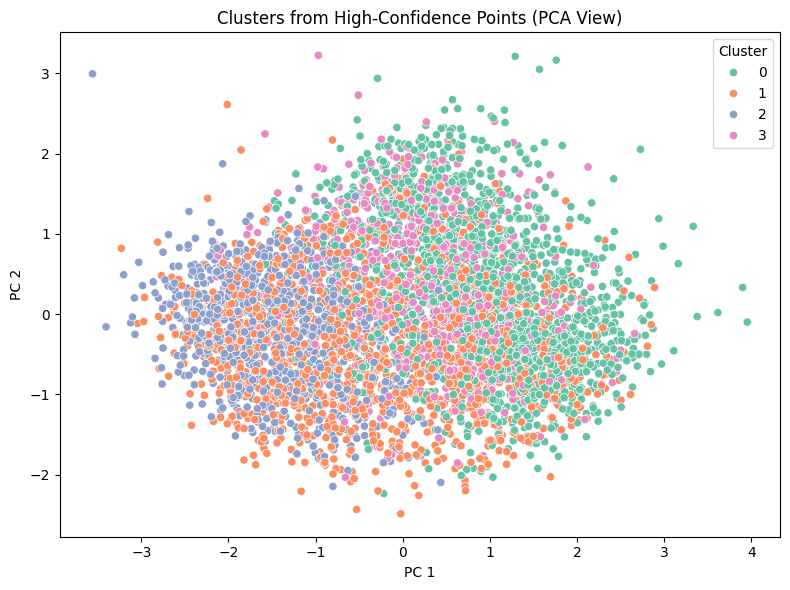

In [15]:
# ------------------------------
# 7. Re-fit GMM on High-Confidence Points
# ------------------------------
from sklearn.mixture import GaussianMixture

# Filter high-confidence points
confident_mask = (df_confidence['avg_post_prob'] > 0.95) & (df_confidence['avg_ari'] > 0.8)
X_confident = X_scaled[confident_mask]

print(f"Using {X_confident.shape[0]} high-confidence points out of {X_scaled.shape[0]} total.")

# Fit new GMM
gmm_confident = GaussianMixture(n_components=k_best, covariance_type='full', random_state=42, n_init=10)
gmm_confident.fit(X_confident)
labels_confident = gmm_confident.predict(X_confident)

# Visualize in PCA space
pca = PCA(n_components=2)
X_pca_confident = pca.fit_transform(X_confident)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_confident[:, 0], y=X_pca_confident[:, 1], hue=labels_confident, palette='Set2')
plt.title("Clusters from High-Confidence Points (PCA View)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [16]:
# ------------------------------
# 8. Retrain on High-Confidence Storms & Predict All
# ------------------------------

# Extract high-confidence subset
X_highconf = X_scaled[confident_mask]

# Retrain GMM
final_gmm = GaussianMixture(n_components=k_best, covariance_type='full', random_state=42, n_init=10)
final_gmm.fit(X_highconf)

# Predict labels and probabilities for *all* storms
all_labels = final_gmm.predict(X_scaled)
all_probs = final_gmm.predict_proba(X_scaled).max(axis=1)

# Add to DataFrame for inspection
df['final_cluster'] = all_labels
df['final_cluster_prob'] = all_probs
df['confidence_category'] = ['High' if mask else 'Low' for mask in confident_mask]


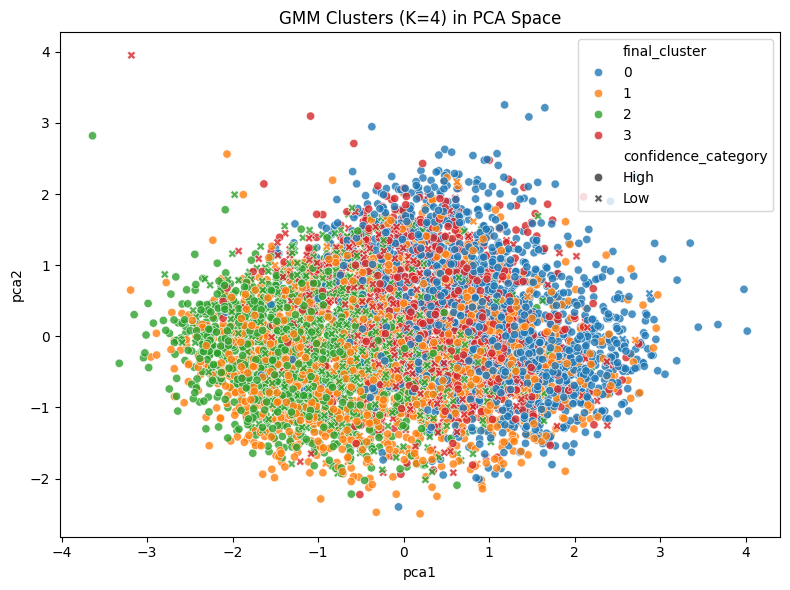

In [17]:
# ------------------------------
# 9. Visualize Clusters in PCA Space
# ------------------------------
pca_vis = PCA(n_components=2, random_state=42)
X_pca = pca_vis.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='final_cluster', style='confidence_category', palette='tab10', alpha=0.8)
plt.title(f"GMM Clusters (K={k_best}) in PCA Space")
plt.tight_layout()
plt.show()


In [18]:
# ------------------------------
# 10. Cluster Summary Statistics
# ------------------------------
summary = df.groupby('final_cluster')[features_to_cluster].agg(['mean', 'std', 'count'])
display(summary)


min_p_cent                 max_p_grad                  \
                    mean       std count       mean       std count   
final_cluster                                                         
0               0.717198  0.713260  1626   2.866303  0.283622  1626   
1              -0.144407  1.039217  1604   3.189178  0.406088  1604   
2              -0.784633  0.759618  1676   3.432033  0.290697  1676   
3               0.309358  0.694178  1230   3.043695  0.295623  1230   

              max_radius                    max_uv                  \
                    mean       std count      mean       std count   
final_cluster                                                        
0               6.594234  0.435764  1626 -0.387354  1.052852  1626   
1               6.808364  0.436402  1604 -0.092483  0.965831  1604   
2               7.082542  0.298338  1676  0.410856  0.834066  1676   
3               6.787273  0.440277  1230  0.072834  0.957603  1230   

              fraction_of_time_in_GLR                  \
                                 mean       std count   
final_cluster                                           
0                            0.457858  0.286476  1626   
1                            0.205260  0.207512  1604   
2                            0.124895  0.091142  1676   
3                            0.291061  0.196100  1230   

              maturity_glr0_minus_genesis_ratio                  
                                           mean       std count  
final_cluster                                                    
0                                      0.840757  0.668445  1626  
1                                     -0.424242  0.000000  1604  
2                                     -0.036110  0.218436  1676  
3                                      0.453079  0.456360  1230

/Users/dannes/etc-cyclones/etc-impacts-great-lakes/env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/dannes/etc-cyclones/etc-impacts-great-lakes/env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


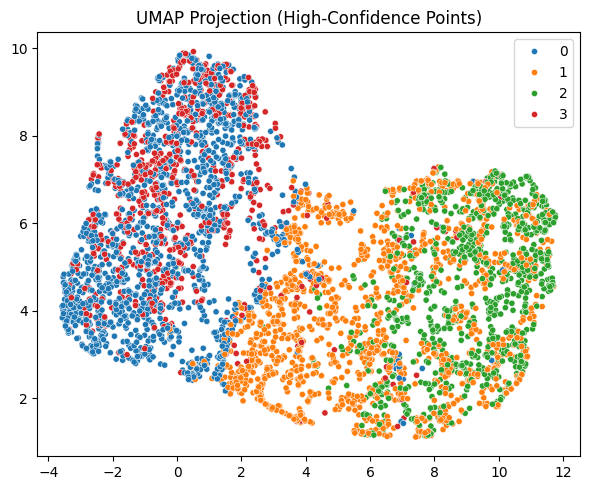

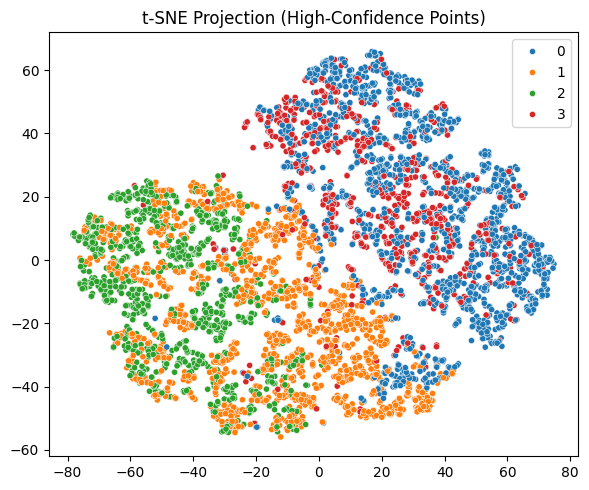

In [19]:
# ------------------------------
# 11. Manifold Visualization (UMAP & t-SNE)
# ------------------------------
from sklearn.manifold import TSNE
import umap.umap_ as umap

# Use high-confidence subset for manifold embedding
X_vis = X_scaled[confident_mask]
y_vis = pd.Categorical(df.loc[confident_mask, 'final_cluster'])

# UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_vis)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_vis, palette='tab10', s=20)
plt.title("UMAP Projection (High-Confidence Points)")
plt.tight_layout()
plt.show()

# t-SNE
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_vis)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_vis, palette='tab10', s=20)
plt.title("t-SNE Projection (High-Confidence Points)")
plt.tight_layout()
plt.show()


In [20]:
# ------------------------------
# 12. Final GMM Models and Export
# ------------------------------
print("\nFitting final K=2 and K=4 GMMs on full data...")

final_gmm_k2 = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=10)
final_gmm_k2.fit(X_scaled)
df['cluster_k2'] = final_gmm_k2.predict(X_scaled)
df['posterior_k2'] = final_gmm_k2.predict_proba(X_scaled).max(axis=1)

final_gmm_k4 = GaussianMixture(n_components=4, covariance_type='full', random_state=42, n_init=10)
final_gmm_k4.fit(X_scaled)
df['cluster_k4'] = final_gmm_k4.predict(X_scaled)
df['posterior_k4'] = final_gmm_k4.predict_proba(X_scaled).max(axis=1)

# Save models
joblib.dump(final_gmm_k2, "../models/gmm_k2.joblib")
joblib.dump(final_gmm_k4, "../models/gmm_k4.joblib")

# Save clustered data
df.to_csv("../processed/era5_clustered.csv", index=False)

print("\n✅ Saved final GMM models and clustered dataset.")


Fitting final K=2 and K=4 GMMs on full data...


FileNotFoundError: [Errno 2] No such file or directory: '../models/gmm_k2.joblib'